# **Titanic: Previsor de Sobrevivência**

Grupo 1 de SI:
Ana Maria,
Eduardo Mabesoone,
Heitor Riquelme,
Pedro Herculano,
Pedro Santana


## **Dataset**

## **Tratamento do Conjunto de Dados**

### **Importações**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.utils import resample

### **Carregamento do Dataset**

In [ ]:
!gdown --id 1AoYeR_iTQuM3V1eMYykZuw8LC6reuerQ
df = pd.read_csv('train.csv')
display(df.head(10))

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1AoYeR_iTQuM3V1eMYykZuw8LC6reuerQ
To: /content/train.csv
100% 61.2k/61.2k [00:00<00:00, 79.5MB/s]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


### **Divisão dos Dados (50% Treino / 25% Validação / 25% Teste)**

In [ ]:
df_train, df_temp = train_test_split(
    df, test_size=0.5, stratify=df['Survived'], random_state=42
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.5, stratify=df_temp['Survived'], random_state=42
)

for nome, split in [('Treino', df_train), ('Validação', df_val), ('Teste', df_test)]:
    n = len(split)
    taxa = split['Survived'].mean()
    print(f'{nome}: {n} amostras | Taxa de sobrevivência: {taxa:.2%}')

Treino: 445 amostras | Taxa de sobrevivência: 38.43%
Validação: 223 amostras | Taxa de sobrevivência: 38.57%
Teste: 223 amostras | Taxa de sobrevivência: 38.12%


### **Análise Exploratória**

In [ ]:
print(df_train.shape)
print(df_train.dtypes)
display(df_train.describe())
print('\nValores nulos por coluna:')
print(df_train.isnull().sum())

(445, 12)
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,445.000000,445.00000,445.000000,354.000000,445.000000,445.000000,445.000000
mean,440.919101,0.38427,2.316854,30.558390,0.422472,0.364045,31.041854
std,265.123246,0.48697,0.838708,14.732869,0.896157,0.787036,45.907556
min,1.000000,0.00000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,211.000000,0.00000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,441.000000,0.00000,3.000000,29.000000,0.000000,0.000000,14.454200
75%,675.000000,1.00000,3.000000,39.000000,1.000000,0.000000,30.000000
max,891.000000,1.00000,3.000000,80.000000,8.000000,5.000000,512.329200



Valores nulos por coluna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             91
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          346
Embarked         1
dtype: int64


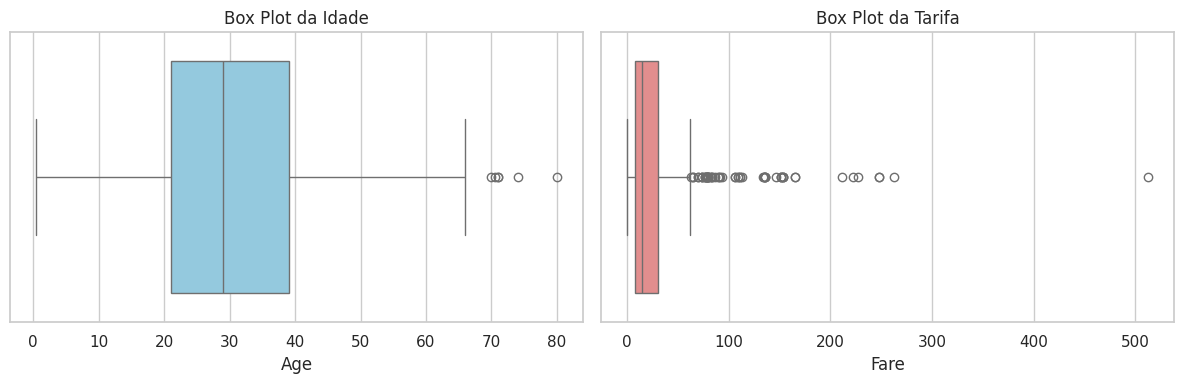

In [ ]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=df_train['Age'].dropna(), ax=axes[0], color='skyblue')
axes[0].set_title('Box Plot da Idade')

sns.boxplot(x=df_train['Fare'], ax=axes[1], color='lightcoral')
axes[1].set_title('Box Plot da Tarifa')

plt.tight_layout()
plt.show()

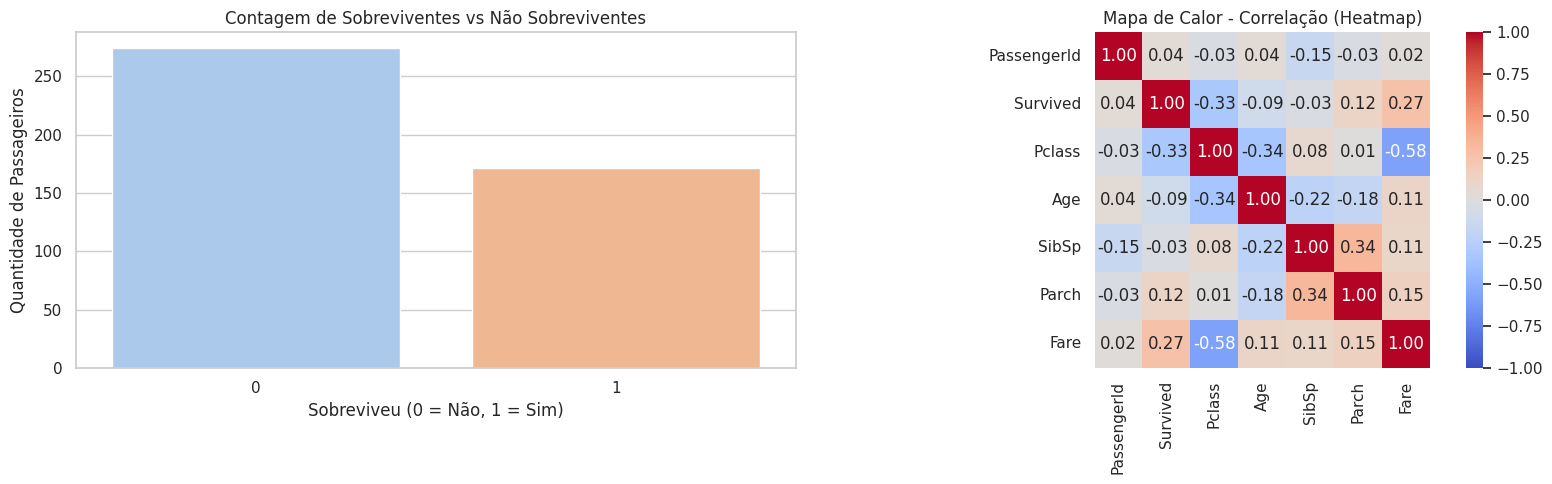

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(x='Survived', data=df_train, ax=axes[0], palette='pastel')
axes[0].set_title('Contagem de Sobreviventes vs Não Sobreviventes')
axes[0].set_xlabel('Sobreviveu (0 = Não, 1 = Sim)')
axes[0].set_ylabel('Quantidade de Passageiros')

colunas_numericas = df_train.select_dtypes(include=['float64', 'int64'])
matriz_correlacao = colunas_numericas.corr()
sns.heatmap(matriz_correlacao, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Mapa de Calor - Correlação (Heatmap)')

plt.tight_layout()
plt.show()

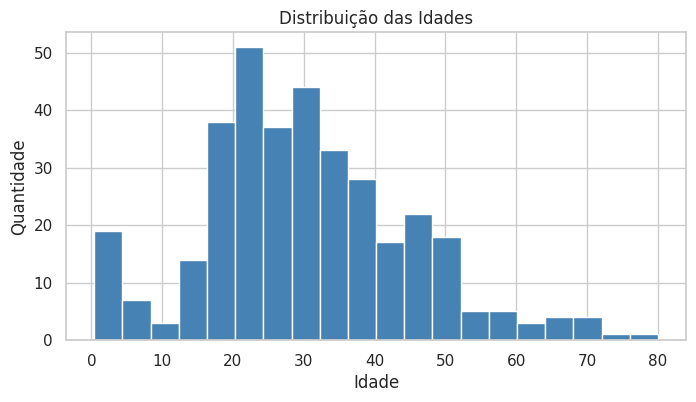

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(df_train['Age'].dropna(), bins=20, color='steelblue', edgecolor='white')
plt.xlabel('Idade')
plt.ylabel('Quantidade')
plt.title('Distribuição das Idades')
plt.show()

In [ ]:
df_train['Cabin_known'] = df_train['Cabin'].notna().astype(int)
survival_by_cabin = df_train.groupby('Cabin_known')['Survived'].mean()
print('Taxa de sobrevivência por conhecimento de cabine:')
print(survival_by_cabin.rename({0: 'Cabine desconhecida', 1: 'Cabine conhecida'}))

Taxa de sobrevivência por conhecimento de cabine:
Cabin_known
Cabine desconhecida    0.297688
Cabine conhecida       0.686869
Name: Survived, dtype: float64


### **Pré-processamento**

In [ ]:
CABINE_LETRAS = list('TGFEDCBA')

COLUNAS_INUTEIS = ['PassengerId', 'Ticket']
COLUNAS_NUMERICAS = ['Fare', 'SibSp', 'Parch']
COLUNAS_CATEGORICAS = ['Pclass', 'Name', 'Sex', 'Cabin', 'Embarked', 'Age_cut']

def extrair_titulo(name: str) -> str:
    rare_patterns = ["Mrs ", "Mr ", "Don", "Jonkheer"]

    title_map = [
        ("Mr.", "Mr."),
        ("Mrs.", "Mrs."),
        ("Miss.", "Miss."),
        ("Master.", "Master."),
        ("Dr.", "Dr."),
        ("Rev.", "Rev."),
        ("Col.", "Col."),
        ("Major.", "Major."),
        ("Mlle.", "Mlle."),
        ("Capt.", "Ms."),
        ("Ms.", "Ms."),
        ("Mme.", "Mme."),
        ("Countess", "Countess"),
    ]

    # Verifica pseudônimos/raros PRIMEIRO
    for pattern in rare_patterns:
        if pattern in name:
            return "Rare"

    # Só então verifica os títulos comuns
    for pattern, title in title_map:
        if pattern in name:
            return title

    return "Unknown"

def extrair_letra_cabine(cabine):
    if pd.isna(cabine):
        return 'NOT_INFORMED'
    for letra in CABINE_LETRAS:
        if letra in str(cabine):
            return letra
    return 'NOT_INFORMED'

def preprocessar(df_input, scaler=None, fit_scaler=False, colunas_treino=None):
    df = df_input.copy().reset_index(drop=True)

    df['Name'] = df['Name'].apply(extrair_titulo)
    df['Cabin'] = df['Cabin'].apply(extrair_letra_cabine)

    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    mediana_por_titulo = df.groupby('Name')['Age'].median()
    df['Age'] = df.apply(
        lambda row: mediana_por_titulo[row['Name']] if pd.isna(row['Age']) else row['Age'],
        axis=1
    )

    df['Age_cut'] = pd.cut(
        df['Age'],
        bins=[0, 18, 25, 40, float('inf')],
        labels=['0-18', '18-25', '25-40', '40+'],
        right=True, include_lowest=True
    )

    df = df.drop(columns=COLUNAS_INUTEIS + ['Age'])

    target = df['Survived']
    df = df.drop(columns=['Survived'])

    if fit_scaler:
        scaler = MinMaxScaler()
        df[['Fare_norm', 'SibSp_norm', 'Parch_norm']] = scaler.fit_transform(df[COLUNAS_NUMERICAS])
    else:
        df[['Fare_norm', 'SibSp_norm', 'Parch_norm']] = scaler.transform(df[COLUNAS_NUMERICAS])
    df = df.drop(columns=COLUNAS_NUMERICAS)

    df = pd.get_dummies(df, columns=COLUNAS_CATEGORICAS)

    if colunas_treino is not None:
        df = df.reindex(columns=colunas_treino, fill_value=0)

    return df, target, scaler

In [ ]:
X_train, y_train, scaler = preprocessar(df_train, fit_scaler=True)
colunas_treino = X_train.columns.tolist()

X_val, y_val, _ = preprocessar(df_val, scaler=scaler, colunas_treino=colunas_treino)
X_test, y_test, _ = preprocessar(df_test, scaler=scaler, colunas_treino=colunas_treino)

print(f'X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')

X_train: (445, 33) | X_val: (223, 33) | X_test: (223, 33)


In [ ]:
X_train.columns

Index(['Cabin_known', 'Fare_norm', 'SibSp_norm', 'Parch_norm', 'Pclass_1',
       'Pclass_2', 'Pclass_3', 'Name_Dr.', 'Name_Major.', 'Name_Master.',
       'Name_Miss.', 'Name_Mr.', 'Name_Mrs.', 'Name_Rare', 'Name_Rev.',
       'Sex_female', 'Sex_male', 'Cabin_A', 'Cabin_B', 'Cabin_C', 'Cabin_D',
       'Cabin_E', 'Cabin_F', 'Cabin_G', 'Cabin_NOT_INFORMED', 'Cabin_T',
       'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Age_cut_0-18',
       'Age_cut_18-25', 'Age_cut_25-40', 'Age_cut_40+'],
      dtype='object')

### **Balanceamento de Classes (Oversampling)**

In [ ]:
print('Distribuição antes do balanceamento:')
print(y_train.value_counts())

train_df = X_train.copy()
train_df['Survived'] = y_train.values

majoritaria = train_df[train_df['Survived'] == 0]
minoritaria = train_df[train_df['Survived'] == 1]

minoritaria_oversampled = resample(
    minoritaria, replace=True,
    n_samples=len(majoritaria),
    random_state=42
)

train_balanceado = pd.concat([majoritaria, minoritaria_oversampled]).sample(frac=1, random_state=42)
X_train_bal = train_balanceado.drop(columns=['Survived'])
y_train_bal = train_balanceado['Survived']

print('\nDistribuição após balanceamento:')
print(y_train_bal.value_counts())

Distribuição antes do balanceamento:
Survived
0    274
1    171
Name: count, dtype: int64

Distribuição após balanceamento:
Survived
0    274
1    274
Name: count, dtype: int64


## **Variação de Hiperparâmetros**

### **Experimento 1 — Função de Ativação**

relu       | Acurácia: 0.8341 | F1: 0.7730
logistic   | Acurácia: 0.8520 | F1: 0.8024
tanh       | Acurácia: 0.8430 | F1: 0.7879


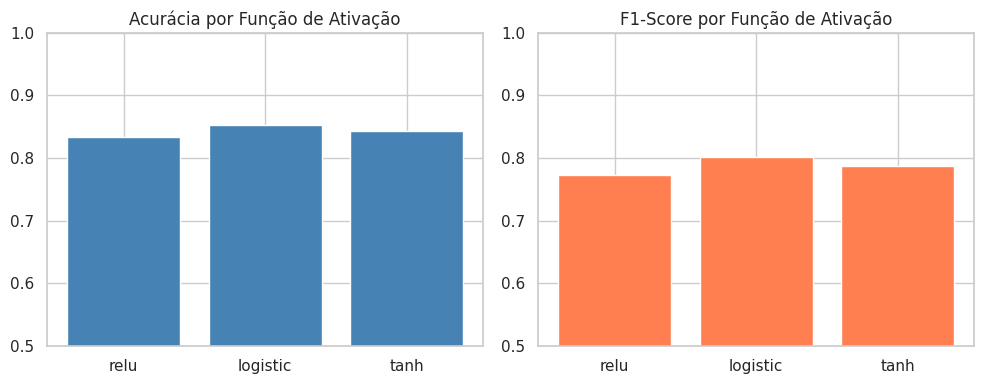

In [ ]:
resultados_activation = []
ativacoes = ['relu', 'logistic', 'tanh']

for act in ativacoes:
    mlp = MLPClassifier(
        hidden_layer_sizes=(100,), activation=act, solver='adam',
        max_iter=500, random_state=42
    )
    mlp.fit(X_train_bal, y_train_bal)
    acc_val = accuracy_score(y_val, mlp.predict(X_val))
    f1_val  = f1_score(y_val, mlp.predict(X_val))
    resultados_activation.append({'Ativação': act, 'Acurácia Val': acc_val, 'F1 Val': f1_val})
    print(f'{act:10s} | Acurácia: {acc_val:.4f} | F1: {f1_val:.4f}')

df_act = pd.DataFrame(resultados_activation)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(df_act['Ativação'], df_act['Acurácia Val'], color='steelblue')
axes[0].set_title('Acurácia por Função de Ativação')
axes[0].set_ylim(0.5, 1.0)
axes[1].bar(df_act['Ativação'], df_act['F1 Val'], color='coral')
axes[1].set_title('F1-Score por Função de Ativação')
axes[1].set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

### **Experimento 2 — Número de Camadas e Neurônios**

(50,)                | Acurácia: 0.8341 | F1: 0.7673
(100,)               | Acurácia: 0.8341 | F1: 0.7730
(200,)               | Acurácia: 0.8206 | F1: 0.7500
(100, 50)            | Acurácia: 0.8251 | F1: 0.7547
(100, 100)           | Acurácia: 0.8251 | F1: 0.7607
(100, 50, 25)        | Acurácia: 0.8341 | F1: 0.7702
(200, 100, 50)       | Acurácia: 0.8206 | F1: 0.7333


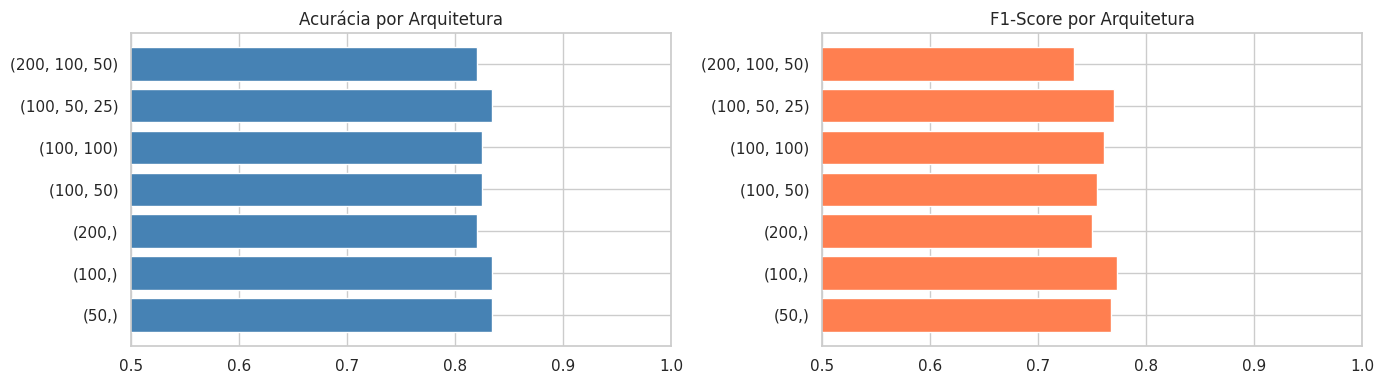

In [ ]:
arquiteturas = [
    (50,), (100,), (200,),
    (100, 50), (100, 100),
    (100, 50, 25), (200, 100, 50)
]

resultados_layers = []
for arq in arquiteturas:
    mlp = MLPClassifier(
        hidden_layer_sizes=arq, activation='relu', solver='adam',
        max_iter=500, random_state=42
    )
    mlp.fit(X_train_bal, y_train_bal)
    acc_val = accuracy_score(y_val, mlp.predict(X_val))
    f1_val  = f1_score(y_val, mlp.predict(X_val))
    resultados_layers.append({'Arquitetura': str(arq), 'Acurácia Val': acc_val, 'F1 Val': f1_val})
    print(f'{str(arq):20s} | Acurácia: {acc_val:.4f} | F1: {f1_val:.4f}')

df_layers = pd.DataFrame(resultados_layers)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].barh(df_layers['Arquitetura'], df_layers['Acurácia Val'], color='steelblue')
axes[0].set_title('Acurácia por Arquitetura')
axes[0].set_xlim(0.5, 1.0)
axes[1].barh(df_layers['Arquitetura'], df_layers['F1 Val'], color='coral')
axes[1].set_title('F1-Score por Arquitetura')
axes[1].set_xlim(0.5, 1.0)
plt.tight_layout()
plt.show()

### **Experimento 3 — Taxa de Aprendizagem**

lr=0.0001 | Acurácia: 0.8520 | F1: 0.7925
lr=0.0010 | Acurácia: 0.8251 | F1: 0.7547
lr=0.0100 | Acurácia: 0.8161 | F1: 0.7355
lr=0.0500 | Acurácia: 0.8251 | F1: 0.7516
lr=0.1000 | Acurácia: 0.8296 | F1: 0.7595


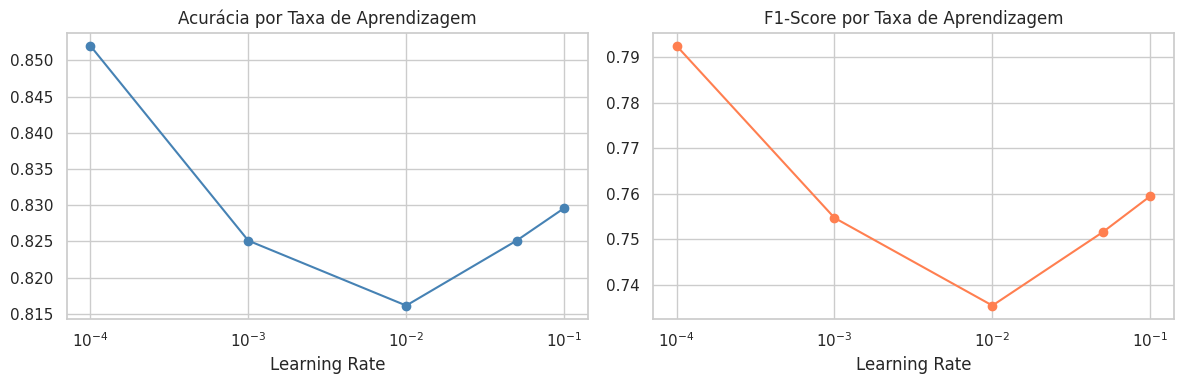

In [ ]:
taxas = [0.0001, 0.001, 0.01, 0.05, 0.1]
resultados_lr = []

for lr in taxas:
    mlp = MLPClassifier(
        hidden_layer_sizes=(100, 50), activation='relu', solver='adam',
        learning_rate_init=lr, max_iter=500, random_state=42
    )
    mlp.fit(X_train_bal, y_train_bal)
    acc_val = accuracy_score(y_val, mlp.predict(X_val))
    f1_val  = f1_score(y_val, mlp.predict(X_val))
    resultados_lr.append({'Taxa': lr, 'Acurácia Val': acc_val, 'F1 Val': f1_val})
    print(f'lr={lr:.4f} | Acurácia: {acc_val:.4f} | F1: {f1_val:.4f}')

df_lr = pd.DataFrame(resultados_lr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df_lr['Taxa'], df_lr['Acurácia Val'], marker='o', color='steelblue')
axes[0].set_xscale('log')
axes[0].set_title('Acurácia por Taxa de Aprendizagem')
axes[0].set_xlabel('Learning Rate')
axes[1].plot(df_lr['Taxa'], df_lr['F1 Val'], marker='o', color='coral')
axes[1].set_xscale('log')
axes[1].set_title('F1-Score por Taxa de Aprendizagem')
axes[1].set_xlabel('Learning Rate')
plt.tight_layout()
plt.show()

### **Experimento 4 — Otimizador (Solver)**

adam     | Acurácia: 0.8251 | F1: 0.7547
sgd      | Acurácia: 0.8296 | F1: 0.7765
lbfgs    | Acurácia: 0.8161 | F1: 0.7320


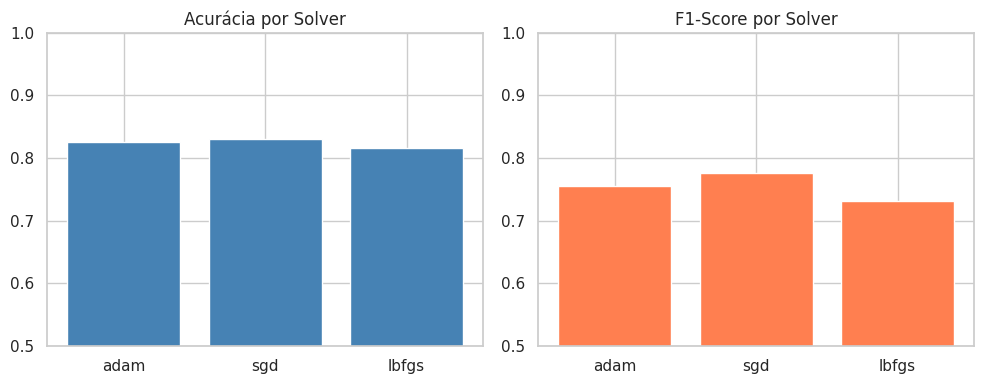

In [ ]:
solvers = ['adam', 'sgd', 'lbfgs']
resultados_solver = []

for solver in solvers:
    mlp = MLPClassifier(
        hidden_layer_sizes=(100, 50), activation='relu', solver=solver,
        max_iter=500, random_state=42
    )
    mlp.fit(X_train_bal, y_train_bal)
    acc_val = accuracy_score(y_val, mlp.predict(X_val))
    f1_val  = f1_score(y_val, mlp.predict(X_val))
    resultados_solver.append({'Solver': solver, 'Acurácia Val': acc_val, 'F1 Val': f1_val})
    print(f'{solver:8s} | Acurácia: {acc_val:.4f} | F1: {f1_val:.4f}')

df_solver = pd.DataFrame(resultados_solver)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(df_solver['Solver'], df_solver['Acurácia Val'], color='steelblue')
axes[0].set_title('Acurácia por Solver')
axes[0].set_ylim(0.5, 1.0)
axes[1].bar(df_solver['Solver'], df_solver['F1 Val'], color='coral')
axes[1].set_title('F1-Score por Solver')
axes[1].set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

### **Experimento 5 — Regularização (Alpha)**

alpha=0.00001 | Acurácia: 0.8251 | F1: 0.7451
alpha=0.00010 | Acurácia: 0.8251 | F1: 0.7547
alpha=0.00100 | Acurácia: 0.8430 | F1: 0.7742
alpha=0.01000 | Acurácia: 0.8386 | F1: 0.7662
alpha=0.10000 | Acurácia: 0.8296 | F1: 0.7500


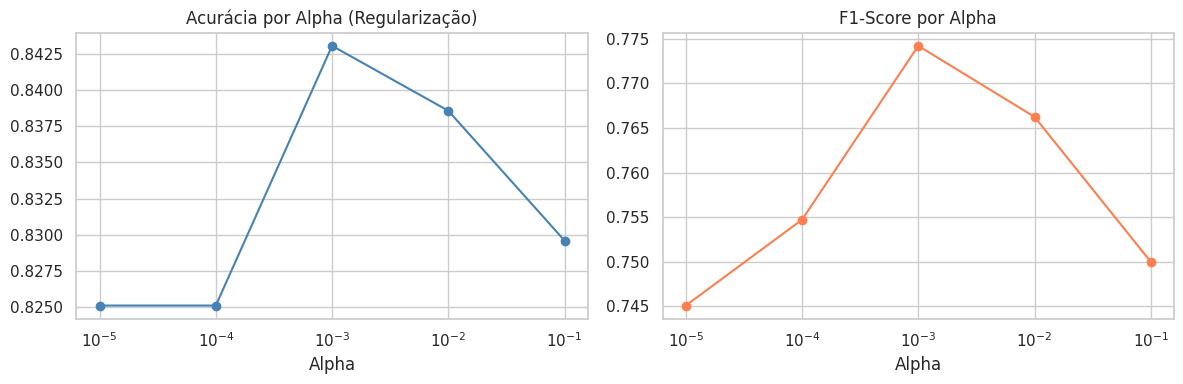

In [ ]:
alphas = [0.00001, 0.0001, 0.001, 0.01, 0.1]
resultados_alpha = []

for alpha in alphas:
    mlp = MLPClassifier(
        hidden_layer_sizes=(100, 50), activation='relu', solver='adam',
        alpha=alpha, max_iter=500, random_state=42
    )
    mlp.fit(X_train_bal, y_train_bal)
    acc_val = accuracy_score(y_val, mlp.predict(X_val))
    f1_val  = f1_score(y_val, mlp.predict(X_val))
    resultados_alpha.append({'Alpha': alpha, 'Acurácia Val': acc_val, 'F1 Val': f1_val})
    print(f'alpha={alpha:.5f} | Acurácia: {acc_val:.4f} | F1: {f1_val:.4f}')

df_alpha = pd.DataFrame(resultados_alpha)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df_alpha['Alpha'], df_alpha['Acurácia Val'], marker='o', color='steelblue')
axes[0].set_xscale('log')
axes[0].set_title('Acurácia por Alpha (Regularização)')
axes[0].set_xlabel('Alpha')
axes[1].plot(df_alpha['Alpha'], df_alpha['F1 Val'], marker='o', color='coral')
axes[1].set_xscale('log')
axes[1].set_title('F1-Score por Alpha')
axes[1].set_xlabel('Alpha')
plt.tight_layout()
plt.show()

### **Resumo dos Experimentos de Hiperparâmetros**

In [ ]:
print('=== Melhores configurações por experimento ===\n')

melhor_act = df_act.loc[df_act['F1 Val'].idxmax()]
print(f'Melhor Ativação : {melhor_act["Ativação"]} | F1: {melhor_act["F1 Val"]:.4f}')

melhor_arq = df_layers.loc[df_layers['F1 Val'].idxmax()]
print(f'Melhor Arquitetura : {melhor_arq["Arquitetura"]} | F1: {melhor_arq["F1 Val"]:.4f}')

melhor_lr = df_lr.loc[df_lr['F1 Val'].idxmax()]
print(f'Melhor Learning Rate: {melhor_lr["Taxa"]} | F1: {melhor_lr["F1 Val"]:.4f}')

melhor_solver = df_solver.loc[df_solver['F1 Val'].idxmax()]
print(f'Melhor Solver : {melhor_solver["Solver"]} | F1: {melhor_solver["F1 Val"]:.4f}')

melhor_alpha = df_alpha.loc[df_alpha['F1 Val'].idxmax()]
print(f'Melhor Alpha : {melhor_alpha["Alpha"]} | F1: {melhor_alpha["F1 Val"]:.4f}')

=== Melhores configurações por experimento ===

Melhor Ativação : logistic | F1: 0.8024
Melhor Arquitetura : (100,) | F1: 0.7730
Melhor Learning Rate: 0.0001 | F1: 0.7925
Melhor Solver : sgd | F1: 0.7765
Melhor Alpha : 0.001 | F1: 0.7742


## **Melhor Modelo**

### **Treinamento do Melhor Modelo**

In [ ]:
melhor_mlp = MLPClassifier(
    hidden_layer_sizes=(200, 100, 50),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    alpha=0.0001,
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)

melhor_mlp.fit(X_train_bal, y_train_bal)
print(f'Treinamento concluído em {melhor_mlp.n_iter_} iterações.')

Treinamento concluído em 32 iterações.


### **Curva de Perda (Loss Curve)**

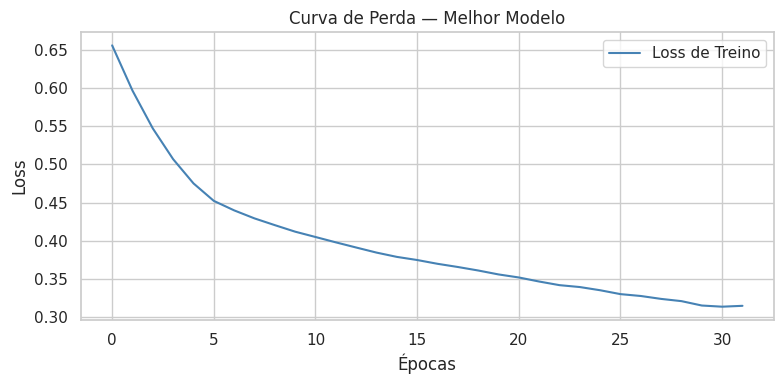

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(melhor_mlp.loss_curve_, color='steelblue', label='Loss de Treino')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Curva de Perda — Melhor Modelo')
plt.legend()
plt.tight_layout()
plt.show()

## **Avaliação de Desempenho**

### **Métricas no Conjunto de Validação**

In [ ]:
y_pred_val = melhor_mlp.predict(X_val)

print('=== Validação ===')
print(f'Acurácia : {accuracy_score(y_val, y_pred_val):.4f}')
print(f'Precisão : {precision_score(y_val, y_pred_val):.4f}')
print(f'Recall : {recall_score(y_val, y_pred_val):.4f}')
print(f'F1-Score : {f1_score(y_val, y_pred_val):.4f}')
print()
print(classification_report(y_val, y_pred_val, target_names=['Não sobreviveu', 'Sobreviveu']))

=== Validação ===
Acurácia : 0.8520
Precisão : 0.8533
Recall : 0.7442
F1-Score : 0.7950

                precision    recall  f1-score   support

Não sobreviveu       0.85      0.92      0.88       137
    Sobreviveu       0.85      0.74      0.80        86

      accuracy                           0.85       223
     macro avg       0.85      0.83      0.84       223
  weighted avg       0.85      0.85      0.85       223



### **Matriz de Confusão — Validação**

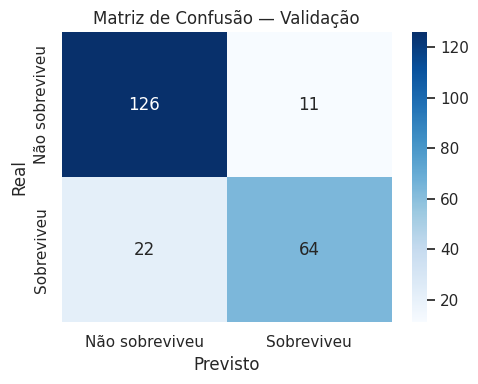

In [ ]:
cm_val = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não sobreviveu', 'Sobreviveu'],
            yticklabels=['Não sobreviveu', 'Sobreviveu'])
plt.title('Matriz de Confusão — Validação')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.tight_layout()
plt.show()

### **Métricas no Conjunto de Teste (Resultado Final)**

In [ ]:
y_pred_test = melhor_mlp.predict(X_test)

print('=== Teste ===')
print(f'Acurácia : {accuracy_score(y_test, y_pred_test):.4f}')
print(f'Precisão : {precision_score(y_test, y_pred_test):.4f}')
print(f'Recall : {recall_score(y_test, y_pred_test):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred_test):.4f}')
print()
print(classification_report(y_test, y_pred_test, target_names=['Não sobreviveu', 'Sobreviveu']))

=== Teste ===
Acurácia : 0.7848
Precisão : 0.7534
Recall : 0.6471
F1-Score : 0.6962

                precision    recall  f1-score   support

Não sobreviveu       0.80      0.87      0.83       138
    Sobreviveu       0.75      0.65      0.70        85

      accuracy                           0.78       223
     macro avg       0.78      0.76      0.76       223
  weighted avg       0.78      0.78      0.78       223



### **Matriz de Confusão — Teste**

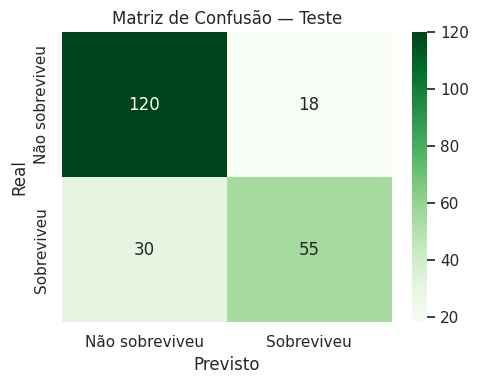

In [ ]:
cm_test = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Não sobreviveu', 'Sobreviveu'],
            yticklabels=['Não sobreviveu', 'Sobreviveu'])
plt.title('Matriz de Confusão — Teste')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.tight_layout()
plt.show()

### **Comparação: Treino vs Validação vs Teste**

,Acurácia,Precisão,Recall,F1-Score
Split,,,,
Treino,0.8376,0.8269,0.8540,0.8402
Validação,0.8520,0.8533,0.7442,0.7950
Teste,0.7848,0.7534,0.6471,0.6962


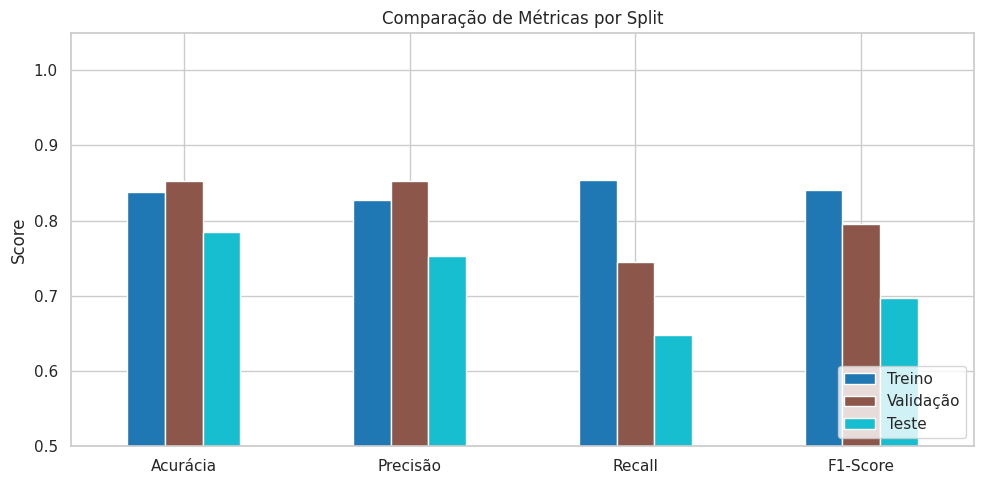

In [ ]:
splits = {
    'Treino'   : (X_train_bal, y_train_bal),
    'Validação': (X_val, y_val),
    'Teste'    : (X_test, y_test),
}

rows = []
for nome, (X, y) in splits.items():
    pred = melhor_mlp.predict(X)
    rows.append({
        'Split'    : nome,
        'Acurácia' : accuracy_score(y, pred),
        'Precisão' : precision_score(y, pred),
        'Recall'   : recall_score(y, pred),
        'F1-Score' : f1_score(y, pred),
    })

df_resultados = pd.DataFrame(rows).set_index('Split')
display(df_resultados.round(4))

df_resultados.T.plot(kind='bar', figsize=(10, 5), colormap='tab10', edgecolor='white')
plt.title('Comparação de Métricas por Split')
plt.ylabel('Score')
plt.ylim(0.5, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### **Entropia Cruzada e MSE**

In [ ]:
from sklearn.metrics import log_loss, mean_squared_error

splits_eval = {
    'Treino'   : (X_train_bal, y_train_bal),
    'Validação': (X_val, y_val),
    'Teste'    : (X_test, y_test),
}

rows_loss = []
for nome, (X, y) in splits_eval.items():
    proba = melhor_mlp.predict_proba(X)
    pred  = melhor_mlp.predict(X)
    ce  = log_loss(y, proba)
    mse = mean_squared_error(y, pred)
    rows_loss.append({'Split': nome, 'Entropia Cruzada': ce, 'MSE': mse})
    print(f'{nome:10s} | Entropia Cruzada: {ce:.4f} | MSE: {mse:.4f}')

df_loss = pd.DataFrame(rows_loss).set_index('Split')
display(df_loss.round(4))

Treino     | Entropia Cruzada: 0.3986 | MSE: 0.1624
Validação  | Entropia Cruzada: 0.3569 | MSE: 0.1480
Teste      | Entropia Cruzada: 0.4618 | MSE: 0.2152


,Entropia Cruzada,MSE
Split,,
Treino,0.3986,0.1624
Validação,0.3569,0.1480
Teste,0.4618,0.2152


### **Visualização — Entropia Cruzada e MSE por Split**

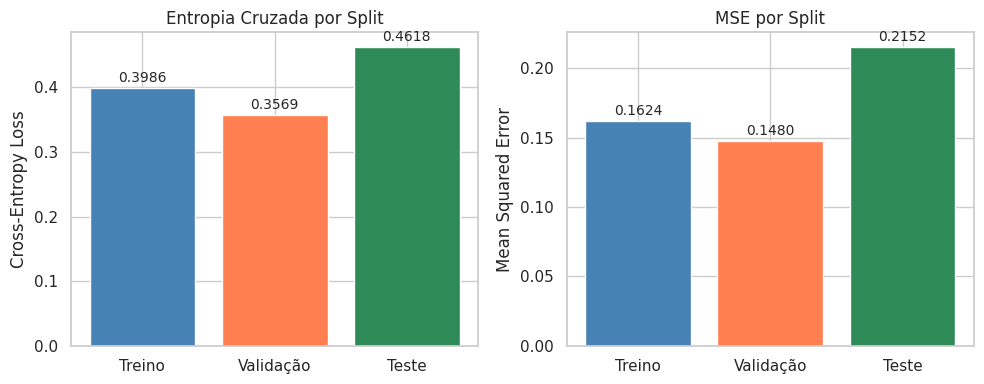

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(df_loss.index, df_loss['Entropia Cruzada'], color=['steelblue', 'coral', 'seagreen'])
axes[0].set_title('Entropia Cruzada por Split')
axes[0].set_ylabel('Cross-Entropy Loss')
for bar, val in zip(axes[0].patches, df_loss['Entropia Cruzada']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10)

axes[1].bar(df_loss.index, df_loss['MSE'], color=['steelblue', 'coral', 'seagreen'])
axes[1].set_title('MSE por Split')
axes[1].set_ylabel('Mean Squared Error')
for bar, val in zip(axes[1].patches, df_loss['MSE']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()